# Zadanie 3
### Jakub Krupa

Napisz program poszukujący rozwiązania łamigłówki Sudoku za pomocą symulowanego
wyżarzania. Plansza 9 × 9 ma zostać wczytana z pliku tekstowego, w którym pola puste
zaznaczone są znakiem x. Jako funkcję kosztu przyjmij sumę powtórzeń cyfr występujących w wierszach bloku 9 × 9, kolumnach bloku 9 × 9 oraz blokach 3 × 3. Zaproponuj metodę generacji stanu sąsiedniego. Przedstaw zależność liczby iteracji algorytmu od liczby pustych miejsc na planszy. Czy Twój program jest w stanie znaleźć poprawne rozwiązanie dla każdej z testowanych konfiguracji wejściowych?


In [1]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

### Załadowania datasetu top95.txt

In [2]:
def load_sudokus_from_txt(filepath):
    grids = []
    i = 1
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if len(line) == 81:
                grid = np.array([int(c) if c != '.' else 0 for c in line])
                free_spaces = sum([1 for num in grid if num==0])
                grids.append({
                    "id": i,
                    "grid": grid.reshape(9,9),
                    "init_free_spaces": free_spaces
                })
                i+=1
    return grids
top95 = load_sudokus_from_txt('./datasets/top95.txt')


In [3]:
def load_sudokus_from_csv(filepath):
    df = pd.read_csv(filepath)
    
    def parse_sudoku_string(puzzle_str):
        grid = np.array([int(c) if c != '.' else 0 for c in str(puzzle_str).strip()])
        return grid.reshape(9, 9)
    
    grids = [{
        "id": i,
        "grid": grid,
        "init_free_spaces": 81 - df['clues'].to_list()[i]
    } for i, grid in enumerate(df['puzzle'].apply(parse_sudoku_string).tolist())]
    return grids

csv_puzzles = load_sudokus_from_csv("./datasets/sudoku-3m.csv")


### Iniclalizacja planszy

Planszę wypełniam wpisując w losowej kolejności liczby, które jeszcze nie wystąpiły w danym bloku 3x3.

In [4]:
def initialize_by_blocks(grid):
    new_grid = grid.copy()
    mask = grid != 0

    for i in range(0,9,3):
        for j in range(0,9,3):
            block = new_grid[i:i+3,j:j+3]
            given_numbers = set(block[block!=0])
            numbers_to_fill = list(set(np.arange(1,10)) - given_numbers)

            np.random.shuffle(numbers_to_fill)

            for k in range(3):
                for l in range(3):
                    if not numbers_to_fill: break
                    block[k][l] = numbers_to_fill.pop() if not block[k][l] else block[k][l]

    return new_grid, mask


def calculate_initial_cost(grid):
    errors = 0
    for i in range(9):
        errors += (9 - len(np.unique(grid[i, :])))
        errors += (9 - len(np.unique(grid[:, i])))
    return errors

### Funkcja obliczająca deltę
Sprawdzam zmianę energii tylko dla rzędów, kolumn i bloków, w których zaszła zmiana

In [5]:
def calculate_delta(grid, p1, p2):
    if p1 == p2: return 0
    r1, c1 = p1
    r2, c2 = p2
    
    b1_r, b1_c = r1 // 3, c1 // 3
    b2_r, b2_c = r2 // 3, c2 // 3
    
    rows_to_check = {r1, r2}
    cols_to_check = {c1, c2}
    blocks_to_check = {(b1_r, b1_c), (b2_r, b2_c)}
    
    def get_block_unique_count(br, bc):
        block = grid[br*3:(br+1)*3, bc*3:(bc+1)*3]
        return len(np.unique(block))

    old_energy = 0
    for r in rows_to_check: old_energy += (9 - len(np.unique(grid[r, :])))
    for c in cols_to_check: old_energy += (9 - len(np.unique(grid[:, c])))
    for br, bc in blocks_to_check: old_energy += (9 - get_block_unique_count(br, bc))
        
    grid[p1], grid[p2] = grid[p2], grid[p1]
    
    new_energy = 0
    for r in rows_to_check: new_energy += (9 - len(np.unique(grid[r, :])))
    for c in cols_to_check: new_energy += (9 - len(np.unique(grid[:, c])))
    for br, bc in blocks_to_check: new_energy += (9 - get_block_unique_count(br, bc))

    grid[p1], grid[p2] = grid[p2], grid[p1]
    
    return new_energy - old_energy


### Funkcje zamiany cyfr
- ```swap_in_block``` - zamiana cyfr wewnątrz bloku 3x3
- ```swap_global``` - zamiana cyfr na całej planszy

In [6]:
def swap_in_block(mask):
    r_off, c_off = np.random.randint(0, 3, 2) * 3
    
    block_mask = mask[r_off:r_off+3, c_off:c_off+3]
    free_rows, free_cols = np.where(~block_mask)

    if len(free_rows) < 2:
        return None, None

    idx1, idx2 = np.random.choice(len(free_rows), 2, replace=False)
    
    p1 = (r_off + free_rows[idx1], c_off + free_cols[idx1])
    p2 = (r_off + free_rows[idx2], c_off + free_cols[idx2])
 
    return p1,p2

def swap_global(mask):
    free_rows, free_cols = np.where(~mask)

    if len(free_rows) < 2:
        return None, None

    idx1, idx2 = np.random.choice(len(free_rows), 2, replace=False)
    
    p1 = (free_rows[idx1], free_cols[idx1])
    p2 = (free_rows[idx2], free_cols[idx2])
    
    return p1, p2

### Estymacja temperatury początkowej

In [7]:
def estimate_t0(grid, mask, target_p=0.8, samples=100, swap_fn=swap_in_block):
        deltas = []
        current_grid = grid.copy()

        for _ in range(samples):
            p1,p2 = swap_fn(mask)

            if p1==p2: continue

            delta = calculate_delta(current_grid, p1, p2)
   
            if delta > 0:
                 deltas.append(delta)

        if not deltas: return 100
        
        avg_delta = np.mean(deltas)
        t0 = -avg_delta / np.log(target_p)

        return t0

### Symulowane Wyzarzanie

In [8]:
def sudoku_annealing(grid,cooling_rate=0.999, freezes = 30, swap_fn = swap_in_block):
    current_grid, mask = initialize_by_blocks(grid)
    current_cost = calculate_initial_cost(current_grid)
    best_grid = current_grid.copy()
    best_cost = current_cost
    t0 = estimate_t0(current_grid, mask, swap_fn=swap_fn)
    temp = t0
    
    iterations = 0

    cost_log = []
    temp_log = []

    while temp > 1e-2 and best_cost>0:

        for _ in range(freezes):

            p1, p2 = swap_fn(mask)
            delta = calculate_delta(current_grid,p1,p2)

            if delta < 0 or np.random.random() < np.exp(-(delta) / temp):
                current_grid[p1],current_grid[p2] = current_grid[p2],current_grid[p1]
                current_cost += delta

                if current_cost < best_cost:
                    best_grid = current_grid.copy()
                    best_cost = current_cost

        cost_log.append(current_cost)
        temp_log.append(temp)        

        iterations+=1
        temp *= cooling_rate

    return best_grid, best_cost, cost_log, temp_log
    



### Funkcja do wizualizacji wyniku wyzarzania

In [9]:
def plot_annealing_results(dist_log, temp_log, title):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color1 = 'royalblue'
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Energy', color=color1)
    ax1.plot(dist_log, color=color1, label='Energy')
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()     
    color2 = 'orange'
    ax2.set_ylabel('Temperature', color=color2)
    ax2.plot(temp_log, color=color2, label='Temperature')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title(title)
    fig.tight_layout() 
    plt.show()



### Zamiana cyfr lokalna (wewnątrz blok 3x3) vs globalna

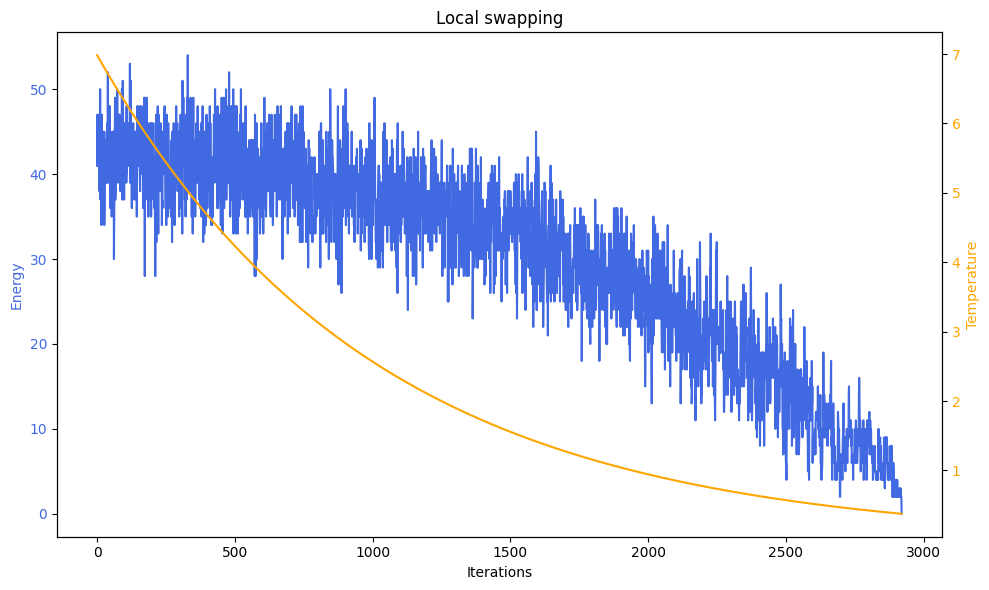

Energy for local swapping: 0


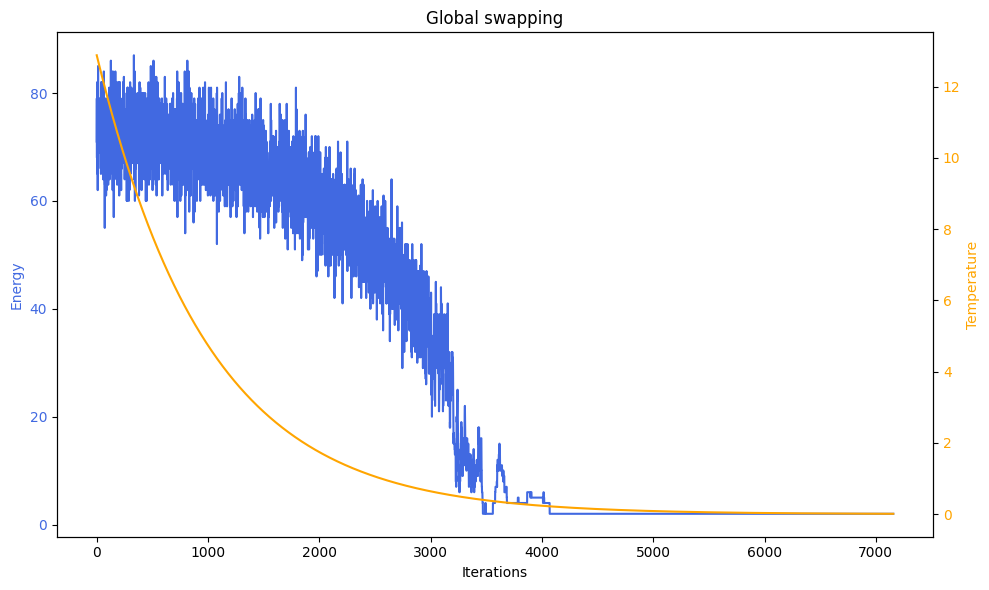

Energy for global swapping: 2


In [10]:
grid, energy, cost_log, temp_log = sudoku_annealing(csv_puzzles[3]['grid'],cooling_rate=0.999,freezes=200, swap_fn=swap_in_block) 

plot_annealing_results(cost_log,temp_log,'Local swapping')
print(f"Energy for local swapping: {energy}")
grid, energy, cost_log, temp_log = sudoku_annealing(csv_puzzles[3]['grid'],cooling_rate=0.999,freezes=200, swap_fn=swap_global) 
plot_annealing_results(cost_log,temp_log,'Global swapping')
print(f"Energy for global swapping: {energy}")

### Zalezność liczby iteracji od pustych miejsc (tylko dla rozwiązanych sudoku)

Teesting 50 sudokus

--------------------------------------------------
[[1 9 8 5 4 3 7 2 6]
 [6 4 3 2 7 8 5 9 1]
 [5 2 7 6 1 9 8 4 3]
 [9 1 4 7 3 5 2 6 8]
 [8 7 6 1 9 2 4 3 5]
 [2 3 5 4 8 6 1 7 9]
 [4 6 2 3 5 1 9 8 7]
 [3 8 1 9 2 7 6 5 4]
 [7 5 9 8 6 4 3 1 2]]
Sudoku 01: OK
Sudoku 02: FAIL (E=2)
Sudoku 03: FAIL (E=2)
[[4 7 3 8 1 6 9 2 5]
 [6 2 8 5 3 9 7 4 1]
 [1 9 5 4 2 7 8 6 3]
 [7 3 2 9 4 8 1 5 6]
 [9 4 1 3 6 5 2 7 8]
 [5 8 6 1 7 2 4 3 9]
 [2 1 7 6 9 3 5 8 4]
 [8 6 4 2 5 1 3 9 7]
 [3 5 9 7 8 4 6 1 2]]
Sudoku 04: OK
[[9 4 7 1 5 3 6 8 2]
 [1 2 8 6 4 9 3 5 7]
 [6 5 3 2 8 7 4 9 1]
 [3 8 1 9 2 6 7 4 5]
 [5 7 2 4 3 8 9 1 6]
 [4 9 6 7 1 5 2 3 8]
 [8 3 9 5 6 2 1 7 4]
 [2 1 5 3 7 4 8 6 9]
 [7 6 4 8 9 1 5 2 3]]
Sudoku 05: OK
[[5 9 8 1 6 3 4 7 2]
 [6 3 2 7 8 4 1 5 9]
 [1 7 4 2 5 9 8 3 6]
 [2 5 9 4 1 8 3 6 7]
 [8 1 6 9 3 7 2 4 5]
 [7 4 3 5 2 6 9 8 1]
 [4 6 5 8 9 2 7 1 3]
 [9 8 1 3 7 5 6 2 4]
 [3 2 7 6 4 1 5 9 8]]
Sudoku 06: OK
[[9 1 3 4 6 8 5 2 7]
 [4 5 8 3 2 7 9 6 1]
 [6 2 7 9 1 5 4 8 3]
 [7 3

ValueError: x and y must be the same size

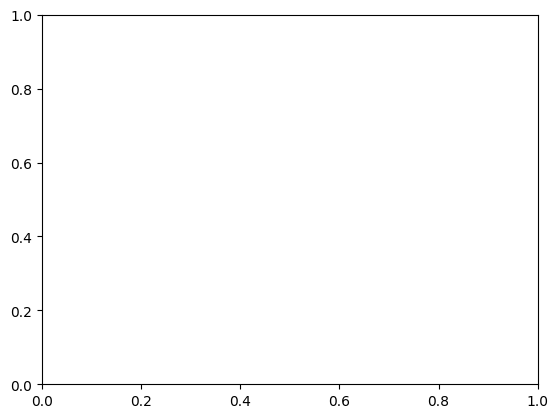

In [ ]:
def plot_free_spaces_vs_iterations(flat_results):
    scores = flat_results[0::3]
    spaces = flat_results[1::3]
    logs = flat_results[2::3]
    
    unique_data = {}
    
    for i in range(len(scores)):

        if scores[i] == 0:
            s = spaces[i]

            if s not in unique_data:
                unique_data[s] = len(logs[i])

    plot_x = list(unique_data.keys())
    plot_y = list(unique_data.values())

    plt.scatter(plot_x, plot_y)
    plt.title('Solved Sudokus: Free Spaces vs Iterations')
    plt.xlabel('Free Spaces')
    plt.ylabel('Iterations')
    plt.show()

def test_annealing(puzzles_dict, cooling_rate=0.9995, swap_fn=swap_in_block):
    results = []
    solved_count = 0

    print(f"Teesting {len(puzzles_dict)} sudokus\n")
    print("-" * 50)

    parallel_results = Parallel(n_jobs=-1)(
        delayed(sudoku_annealing)(
            grid=puzzle['grid'], 
            cooling_rate=cooling_rate, 
            freezes=200, 
            swap_fn=swap_fn, 
            ) 
        for puzzle in puzzles_dict
    )

    for i,(final_grid, score, log,_ )in enumerate(parallel_results):
        status = "OK" if score == 0 else f"FAIL (E={score})"
        
        if score == 0:
            print(final_grid)
            solved_count += 1
            
        print(f"Sudoku {i+1:02d}: {status}")
        results.append(score)
        results.append(puzzles_dict[i]['init_free_spaces'])
        results.append(log)
    
    print("-" * 50)
    print(f"Finished:")
    print(f"Solved: {solved_count}/{len(puzzles_dict)} ({(solved_count/len(puzzles_dict))*100:.1f}%)")
    
    return results

result = test_annealing(csv_puzzles[:50], cooling_rate=0.999, swap_fn=swap_in_block )

plot_free_spaces_vs_iterations(result)



### Próba rozwiązania sudoku z datasetu top95.txt

In [ ]:
result = test_annealing(top95, cooling_rate=0.999, swap_fn=swap_in_block )